# 03 Modeling SARIMAX — Forecast Test (2016–2025)

---
## Setup & Load Data Bulanan

Membaca hasil agregasi bulanan dari `dataset/monthly_aggregated.csv` (dihasilkan oleh notebook **02 Feature Engineering**).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')


In [2]:
# Konstanta kolom (sesuai notebook 01/02)
COL_TEMP_2M_MEAN = 'temperature_2m_mean'
COL_PRECIPITATION_SUM = 'precipitation_sum'
COL_SOIL_MOIST_0_7CM_MEAN = 'soil_moisture_0_7cm_mean'
COL_SOIL_TEMP_0_7CM_MEAN = 'soil_temperature_0_7cm_mean'
COL_RELATIVE_HUMIDITY_2M_MEAN = 'relative_humidity_2m_mean'
COL_SUNSHINE_DURATION = 'sunshine_duration'
COL_PRECIPITATION_HOURS_SUM = 'precipitation_hours'
COL_CLOUD_COVER_MEAN = 'cloud_cover_mean'

TARGETS = [COL_TEMP_2M_MEAN, COL_PRECIPITATION_SUM,
           COL_SOIL_MOIST_0_7CM_MEAN, COL_SOIL_TEMP_0_7CM_MEAN]
EXOG    = [COL_RELATIVE_HUMIDITY_2M_MEAN, COL_SUNSHINE_DURATION,
           COL_PRECIPITATION_HOURS_SUM, COL_CLOUD_COVER_MEAN]

TARGET_LABELS = {
    COL_TEMP_2M_MEAN: 'Suhu Udara (°C)',
    COL_PRECIPITATION_SUM: 'Curah Hujan (mm)',
    COL_SOIL_MOIST_0_7CM_MEAN: 'Kelembaban Tanah (m³/m³)',
    COL_SOIL_TEMP_0_7CM_MEAN: 'Suhu Tanah (°C)',
}

# Load data bulanan
MONTHLY_CSV_PATH = 'dataset/monthly_aggregated.csv'
df_m = pd.read_csv(MONTHLY_CSV_PATH, parse_dates=['time'], index_col='time')
df_m.index.freq = 'MS'

# Split train / test
SPLIT_DATE = '2016-01-01'
train = df_m.loc[:'2015-12-31']
test  = df_m.loc[SPLIT_DATE:]

# Standardize exogenous (fit di train)
exog_mean  = train[EXOG].mean()
exog_std   = train[EXOG].std()
exog_train = (train[EXOG] - exog_mean) / exog_std
exog_test  = (test[EXOG]  - exog_mean) / exog_std

print(f'Periode penuh : {df_m.index.min().date()} → {df_m.index.max().date()}  ({len(df_m)} bulan)')
print(f'Train         : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} bulan)')
print(f'Test          : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} bulan)')
print(f'exog_train: {exog_train.shape}   exog_test: {exog_test.shape}')
df_m.head()


Periode penuh : 1940-01-01 → 2025-12-01  (1032 bulan)
Train         : 1940-01-01 → 2015-12-01  (912 bulan)
Test          : 2016-01-01  → 2025-12-01  (120 bulan)
exog_train: (912, 4)   exog_test: (120, 4)


,temperature_2m_mean,precipitation_sum,soil_moisture_0_7cm_mean,soil_temperature_0_7cm_mean,relative_humidity_2m_mean,sunshine_duration,cloud_cover_mean,precipitation_hours
time,,,,,,,,
1940-01-01,23.080000,350.6,0.492667,24.280000,89.166667,733343.61,96.366667,439.0
1940-02-01,23.496552,169.2,0.487862,24.713793,87.344828,1013801.51,88.896552,293.0
1940-03-01,24.332258,129.2,0.451000,25.841935,85.290323,1270174.02,75.709677,205.0
1940-04-01,24.460000,158.5,0.443300,26.056667,86.033333,1167446.56,66.866667,270.0
1940-05-01,23.961290,230.5,0.485677,25.341935,88.967742,957003.79,87.935484,339.0


---
## Time Series Cross-Validation (Fixed Windows)

4 fold dengan window test 10 tahun: 1960–1969, 1970–1979, 1990–1999, 2000–2009. Tiap fold: train = semua data `df_m` sebelum window test. Exogenous distandardisasi per fold (fit di train fold) untuk hindari data leakage. Setelah CV ini, model di-fit ulang pada train 1940–2015 dan dievaluasi pada hold-out 2016–2025.

In [ ]:
# Fixed-window time series CV (runs before main fit)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Order kandidat: (p,d,q)(P,D,Q,m)
ORDERS = {
    COL_TEMP_2M_MEAN:          ((1, 1, 4), (1, 1, 1, 12)),
    COL_PRECIPITATION_SUM:     ((0, 1, 1), (0, 1, 1, 12)),
    COL_SOIL_MOIST_0_7CM_MEAN: ((1, 0, 2), (1, 1, 1, 12)),
    COL_SOIL_TEMP_0_7CM_MEAN:  ((2, 1, 4), (2, 1, 0, 12)),
}

def _r2(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

CV_WINDOWS = [
    ('1960-01-01', '1969-12-01'),
    ('1970-01-01', '1979-12-01'),
    ('1990-01-01', '1999-12-01'),
    ('2000-01-01', '2009-12-01'),
]

cv_records = []
cv_forecasts = {col: [] for col in TARGETS}

for fold_idx, (test_start, test_end) in enumerate(CV_WINDOWS, start=1):
    train_fold = df_m.loc[:pd.Timestamp(test_start) - pd.offsets.MonthBegin(1)]
    test_fold  = df_m.loc[test_start:test_end]

    # Standardize exog per fold (fit di train fold saja)
    mu = train_fold[EXOG].mean()
    sd = train_fold[EXOG].std()
    exog_tr = (train_fold[EXOG] - mu) / sd
    exog_te = (test_fold[EXOG]  - mu) / sd

    for col, (order, sorder) in ORDERS.items():
        y_tr = train_fold[col].loc[exog_tr.index]
        y_te = test_fold[col].loc[exog_te.index]

        # with exog
        res = SARIMAX(
            y_tr, exog=exog_tr,
            order=order, seasonal_order=sorder,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        yhat = res.get_forecast(steps=len(y_te), exog=exog_te).predicted_mean
        cv_forecasts[col].append(pd.Series(yhat.values, index=y_te.index))

        rmse = np.sqrt(((y_te - yhat) ** 2).mean())
        mae  = (y_te - yhat).abs().mean()
        mape = (y_te - yhat).abs().div(y_te.abs().replace(0, np.nan)).mean() * 100
        r2   = _r2(y_te, yhat)
        cv_records.append({
            'Target': col, 'Variant': 'with exog', 'Fold': fold_idx,
            'TrainEnd': train_fold.index[-1].date(),
            'TestStart': test_fold.index[0].date(), 'TestEnd': test_fold.index[-1].date(),
            'RMSE': round(rmse, 3), 'MAE': round(mae, 3),
            'MAPE': round(mape, 2), 'R2': round(r2, 4),
        })

        # no exog
        res_ne = SARIMAX(
            y_tr,
            order=order, seasonal_order=sorder,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        yhat_ne = res_ne.get_forecast(steps=len(y_te)).predicted_mean

        rmse_ne = np.sqrt(((y_te - yhat_ne) ** 2).mean())
        mae_ne  = (y_te - yhat_ne).abs().mean()
        mape_ne = (y_te - yhat_ne).abs().div(y_te.abs().replace(0, np.nan)).mean() * 100
        r2_ne   = _r2(y_te, yhat_ne)
        cv_records.append({
            'Target': col, 'Variant': 'no exog', 'Fold': fold_idx,
            'TrainEnd': train_fold.index[-1].date(),
            'TestStart': test_fold.index[0].date(), 'TestEnd': test_fold.index[-1].date(),
            'RMSE': round(rmse_ne, 3), 'MAE': round(mae_ne, 3),
            'MAPE': round(mape_ne, 2), 'R2': round(r2_ne, 4),
        })

cv_df = pd.DataFrame(cv_records)

cv_summary = (
    cv_df.groupby(['Target', 'Variant'])[['RMSE', 'MAE', 'MAPE', 'R2']]
    .agg(['mean', 'std'])
    .round(3)
)

print('Per-fold metrics:')
display(cv_df)
print('\nMean ± Std across folds:')
display(cv_summary)

---
## Fit SARIMAX & Forecast Test (2016–2025)

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Order kandidat: (p,d,q)(P,D,Q,m)
ORDERS = {
    COL_TEMP_2M_MEAN:          ((1, 1, 4), (1, 1, 1, 12)),
    COL_PRECIPITATION_SUM:     ((0, 1, 1), (0, 1, 1, 12)),
    COL_SOIL_MOIST_0_7CM_MEAN: ((1, 0, 2), (1, 1, 1, 12)),
    COL_SOIL_TEMP_0_7CM_MEAN:  ((2, 1, 4), (2, 1, 0, 12)),
}

fits, forecasts, conf_ints = {}, {}, {}
fits_noexog, forecasts_noexog, conf_ints_noexog = {}, {}, {}
metrics = []

def _r2(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

for col, (order, sorder) in ORDERS.items():
    # Align endog ke index exog (jaga jika exog di-diff -> kehilangan baris awal)
    y_train = train[col].loc[exog_train.index]
    y_test  = test[col].loc[exog_test.index]

    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        seasonal_order=sorder,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    model_without_exog = SARIMAX(
        y_train,
        order=order,
        seasonal_order=sorder,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)
    res_noexog = model_without_exog.fit(disp=False)
    fits[col] = res
    fits_noexog[col] = res_noexog

    fc   = res.get_forecast(steps=len(y_test), exog=exog_test)
    yhat = fc.predicted_mean
    ci   = fc.conf_int(alpha=0.05)
    forecasts[col] = yhat
    conf_ints[col] = ci

    fc_ne   = res_noexog.get_forecast(steps=len(y_test))
    yhat_ne = fc_ne.predicted_mean
    ci_ne   = fc_ne.conf_int(alpha=0.05)
    forecasts_noexog[col] = yhat_ne
    conf_ints_noexog[col] = ci_ne

    rmse = np.sqrt(((y_test - yhat) ** 2).mean())
    mae  = (y_test - yhat).abs().mean()
    mape = (y_test - yhat).abs().div(y_test.abs()).mean() * 100
    r2   = _r2(y_test, yhat)
    metrics.append({'Target': col, 'Variant': 'with exog',
                    'order': order, 'seasonal_order': sorder,
                    'AIC': round(res.aic, 2), 'RMSE': round(rmse, 2),
                    'MAE': round(mae, 2), 'MAPE': f"{mape:.2f}%",
                    'R2': round(r2, 4)})

    rmse_ne = np.sqrt(((y_test - yhat_ne) ** 2).mean())
    mae_ne  = (y_test - yhat_ne).abs().mean()
    mape_ne = (y_test - yhat_ne).abs().div(y_test.abs()).mean() * 100
    r2_ne   = _r2(y_test, yhat_ne)
    metrics.append({'Target': col, 'Variant': 'no exog',
                    'order': order, 'seasonal_order': sorder,
                    'AIC': round(res_noexog.aic, 2), 'RMSE': round(rmse_ne, 2),
                    'MAE': round(mae_ne, 2), 'MAPE': f"{mape_ne:.2f}%",
                    'R2': round(r2_ne, 4)})

display(pd.DataFrame(metrics).style.set_properties(**{'text-align': 'left'}))

/mnt/data/_Kuliah/Departemen/Semester 6/Data Mining/Project Akhir/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/data/_Kuliah/Departemen/Semester 6/Data Mining/Project Akhir/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/data/_Kuliah/Departemen/Semester 6/Data Mining/Project Akhir/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/data/_Kuliah/Departemen/Semester 6/Data Mining/Project Akhir/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

,Target,Variant,order,seasonal_order,AIC,RMSE,MAE,MAPE,R2
0,temperature_2m_mean,with exog,"(1, 1, 4)","(1, 1, 1, 12)",-257.030000,0.340000,0.270000,1.03%,0.785800
1,temperature_2m_mean,no exog,"(1, 1, 4)","(1, 1, 1, 12)",791.250000,0.890000,0.740000,2.82%,-0.510600
2,precipitation_sum,with exog,"(0, 1, 1)","(0, 1, 1, 12)",9279.360000,46.690000,33.970000,18.89%,0.856500
3,precipitation_sum,no exog,"(0, 1, 1)","(0, 1, 1, 12)",10239.900000,85.740000,64.930000,44.93%,0.516100
4,soil_moisture_0_7cm_mean,with exog,"(1, 0, 2)","(1, 1, 1, 12)",-5361.480000,0.050000,0.040000,9.32%,0.571500
5,soil_moisture_0_7cm_mean,no exog,"(1, 0, 2)","(1, 1, 1, 12)",-3861.880000,0.070000,0.050000,13.85%,0.190500
6,soil_temperature_0_7cm_mean,with exog,"(2, 1, 4)","(2, 1, 0, 12)",661.910000,0.660000,0.530000,1.95%,0.705900
7,soil_temperature_0_7cm_mean,no exog,"(2, 1, 4)","(2, 1, 0, 12)",1359.540000,1.110000,0.870000,3.13%,0.166800


---
## Visualisasi Forecast vs Aktual

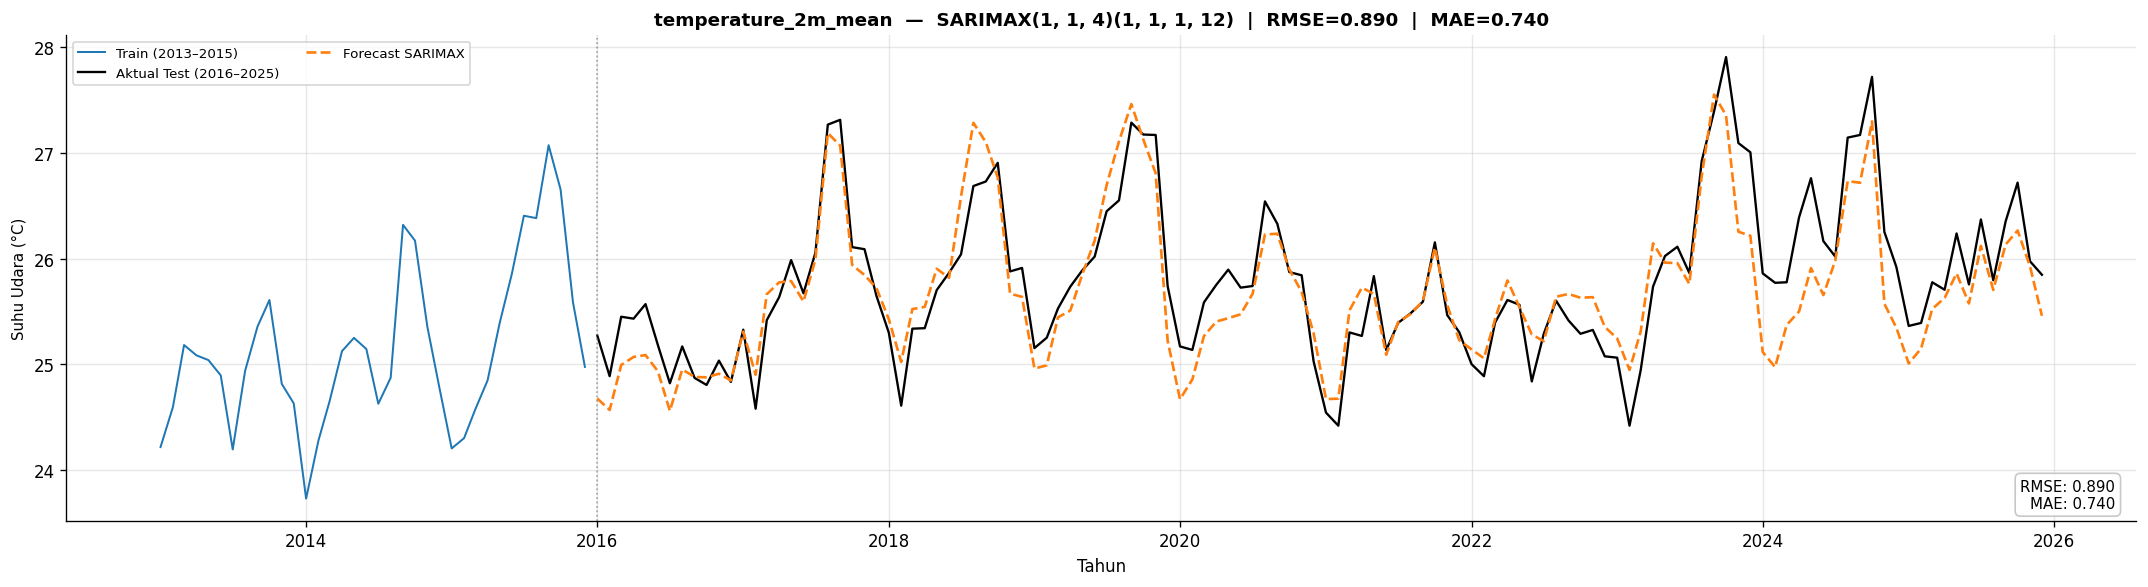

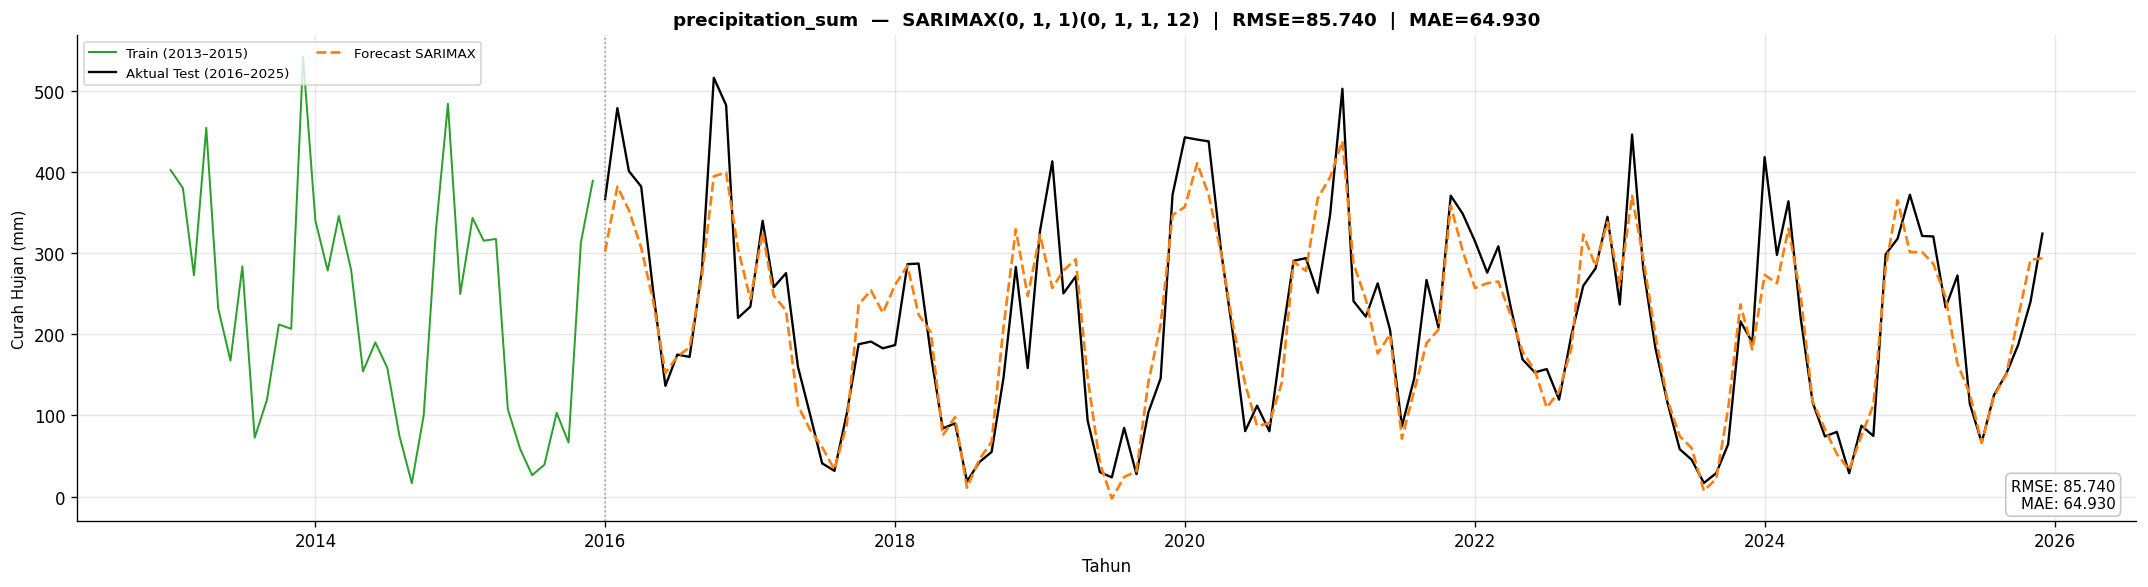

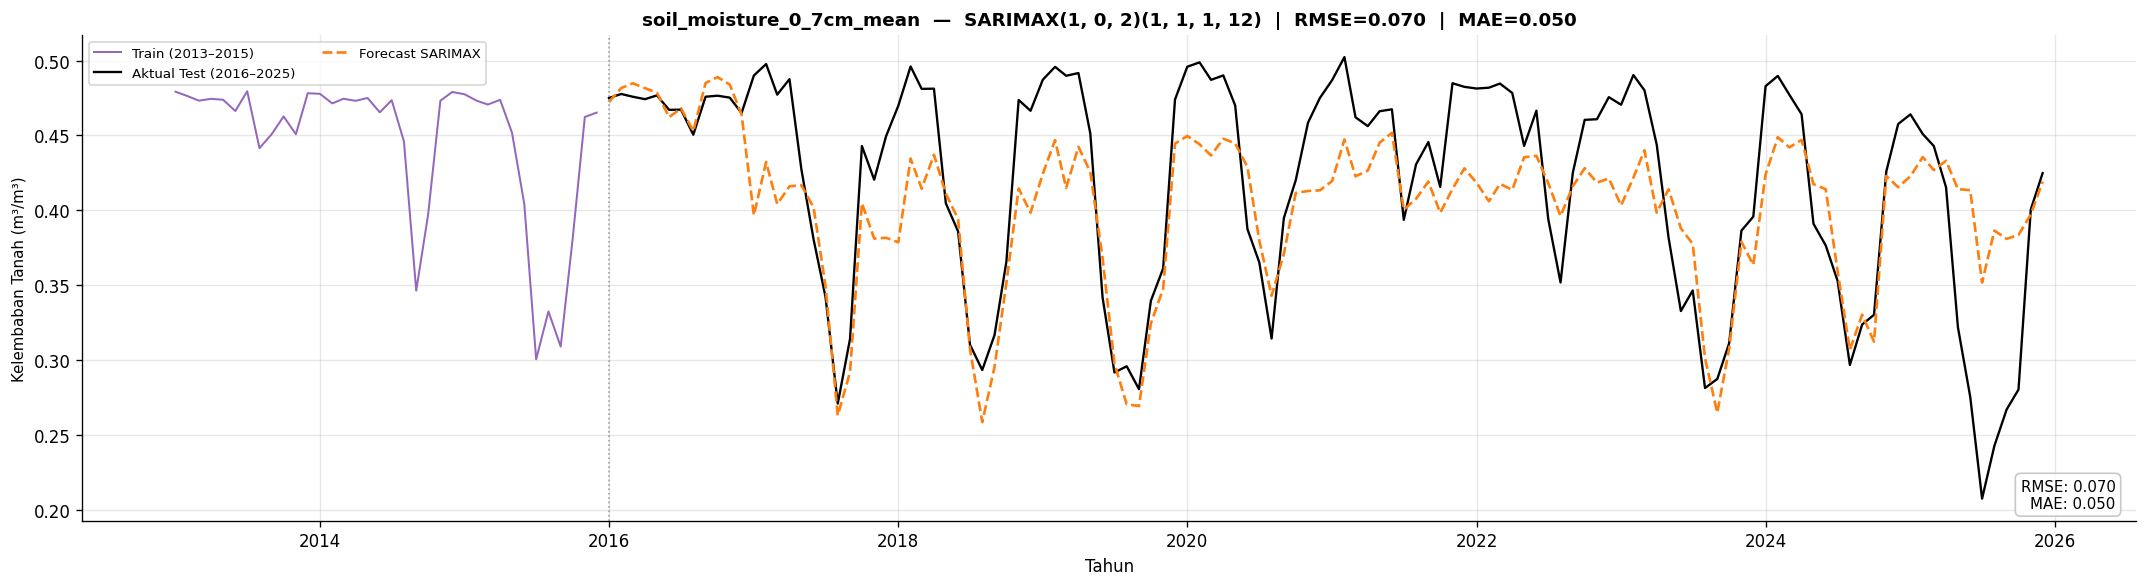

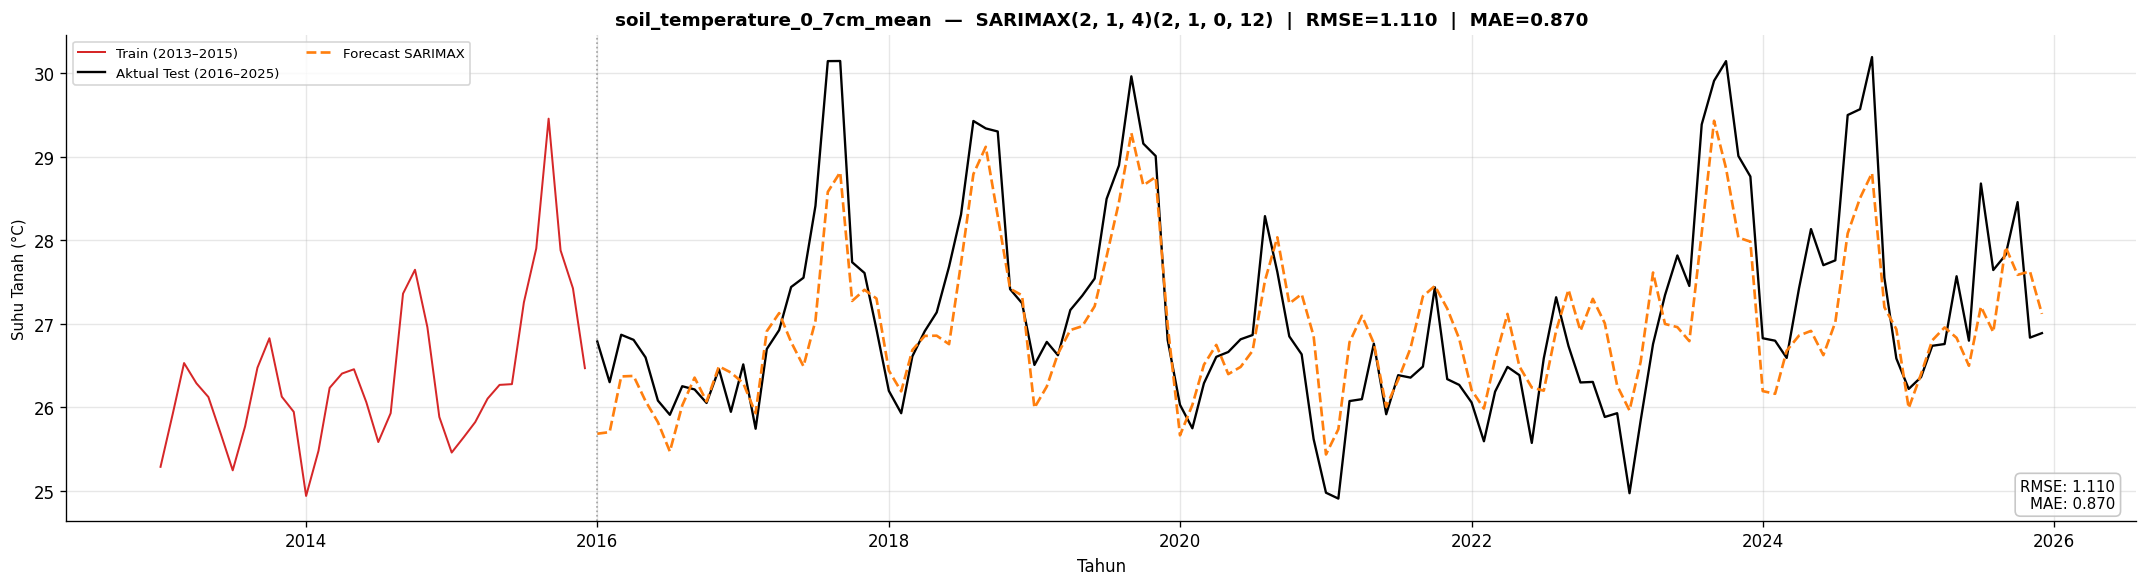

In [5]:
# Plot forecast window 2013-2025: one figure per target
PLOT_START = '2013-01-01'
plot_colors = dict(zip(TARGETS, ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']))
metrics_by_target = {m['Target']: m for m in metrics}

for col in TARGETS:
    c = plot_colors[col]
    train_win = train[col].loc[PLOT_START:]
    test_win = test[col]
    yhat = forecasts[col]
    ci = conf_ints[col]
    lower = ci.iloc[:, 0]
    upper = ci.iloc[:, 1]

    metric_row = metrics_by_target[col]
    rmse = float(metric_row['RMSE'])
    mae = float(metric_row['MAE'])

    fig, ax = plt.subplots(figsize=(18, 5))
    ax.plot(train_win.index, train_win.values, color=c, lw=1.2, label='Train (2013–2015)')
    ax.plot(test_win.index, test_win.values, color='black', lw=1.4, label='Aktual Test (2016–2025)')
    ax.plot(yhat.index, yhat.values, color='#ff7f0e', lw=1.6, linestyle='--', label='Forecast SARIMAX')
    # ax.fill_between(yhat.index, lower.values, upper.values, color='#ff7f0e', alpha=0.15, label='95% CI')
    ax.axvline(pd.Timestamp(SPLIT_DATE), color='gray', lw=1, linestyle=':', alpha=0.7)

    order, sorder = ORDERS[col]
    ax.set_title(f'{col}  —  SARIMAX{order}{sorder}  |  RMSE={rmse:.3f}  |  MAE={mae:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel(TARGET_LABELS[col], fontsize=9)
    ax.set_xlabel('Tahun')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

    metrics_box = f'RMSE: {rmse:.3f}\nMAE: {mae:.3f}'
    ax.text(
        0.99,
        0.02,
        metrics_box,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        bbox={
            'boxstyle': 'round,pad=0.35',
            'facecolor': 'white',
            'alpha': 0.85,
            'edgecolor': '0.75',
        },
    )

    plt.tight_layout()
    plt.show()